# Inference in Discrete-Time Dynamical Systems via Simulation

In this tutorial, we show how we can use a simulator to "unroll" a discrete-time dynamical system into a standard `numpyro` probabilistic program and perform inference accordingly.

## The System

In this example, we'll use a stochastic, discrete-time version of the Lorenz 63 model. The state evolution will be specified as 

$$ x_{t+1} = \left( I + 0.01\begin{bmatrix} -10 & 10 & 0 \\ \rho - x_{t,2} & -1 & 0 \\ x_{t,1} & 0 & \frac{-8}{3} \end{bmatrix} \right) x_{t} + \varepsilon_t; \qquad \varepsilon_t \sim \mathcal{N}(0.0, 0.01 I), $$

where $I$ is the identity matrix and the transition depends on some parameter $\rho$. 

Let's set up a probabilistic program for this dynamical system, putting a uniform $U(10.0, 40.0)$ prior on $\rho$. Our observations will be a noisy version of the first component, $x_{t, 1}$. When we write the corresponding `state_evolution`, we will always write in terms of $t_{\text{now}}$ and $t_{\text{next}}$ to avoid potential ambiguity in $t$ (these serve the same role as $x_t$ and $x_{t+1}$ above, but are a bit more readable in code):

In [1]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
from dsx.dynamical_models import DynamicalModel
from dsx.observations import LinearGaussianObservation
import dsx

def discrete_time_l63_model(rho=None):
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0), obs=rho)

    def drift(x):
        return jnp.array(
            [
                10.0 * (x[1] - x[0]),
                x[0] * (rho - x[2]) - x[1],
                x[0] * x[1] - (8.0 / 3.0) * x[2],
            ]
        )

    def state_evolution(x, u, t_now, t_next):
        loc = x + 0.01 * drift(x)
        cov = 0.01 * jnp.eye(3)
        return dist.MultivariateNormal(loc=loc, covariance_matrix=cov)

    # Create the dynamical model with sampled rho
    dynamics = DynamicalModel(
        state_dim=3,
        observation_dim=1,
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(3), covariance_matrix=20.0**2 * jnp.eye(3)
        ),
        state_evolution=state_evolution,
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]), R=jnp.array([[1.0**2]])
        ),
    )

    return dsx.sample_ds("f", dynamics)

## Generating Samples From the Generative Model

As in our previous examples, we must specify a `dsx.simulators` object to tell `dynestyx` how to generate samples. For discrete-time dynamical systems, we can use the `dsx.simulators.DiscreteTimeSimulator`.

In [2]:
from dsx.simulators import DiscreteTimeSimulator
from dsx.ops import Trajectory, Context
from dsx.handlers import Condition
import jax.random as jr
from numpyro.infer import Predictive

obs_times = jnp.arange(start=1.0, stop=1000.0, step=1.0)
context = Context(observations=Trajectory(times=obs_times))

prng_key = jr.PRNGKey(0)
sde_solver_key, predictive_key = jr.split(prng_key, 2)

predictive_model = Predictive(discrete_time_l63_model, num_samples=1)

with DiscreteTimeSimulator():
    with Condition(context=context):
        synthetic_samples = predictive_model(predictive_key, rho=28.0)


/Users/danwaxman/Documents/dynestyx/dsx/dynamical_models.py:54: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


We can visualize the resulting dynamical system and observations:

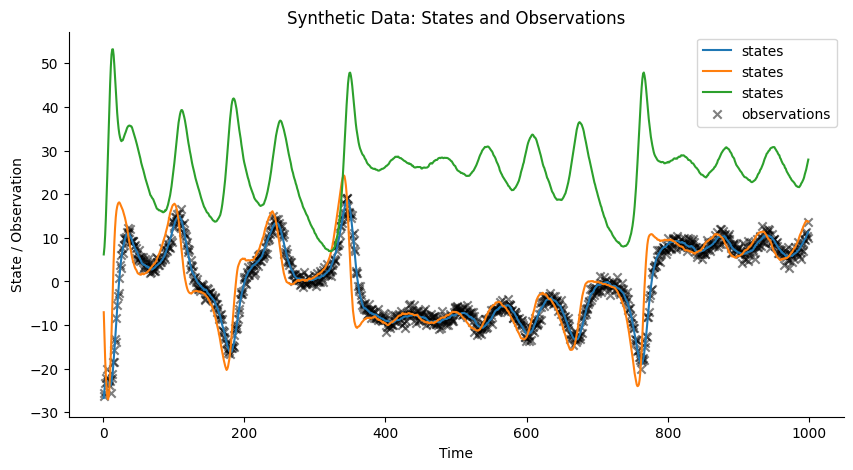

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

plt.plot(synthetic_samples["times"][0], synthetic_samples["states"][0], label="states")
plt.scatter(
    synthetic_samples["times"][0],
    synthetic_samples["observations"][0],
    label="observations",
    marker="x",
    color="black",
    alpha=0.5,
)
plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("State / Observation")
sns.despine()
plt.legend()
plt.show()

We can also visualize in 3d to see the typical Lorenz attractor shape.

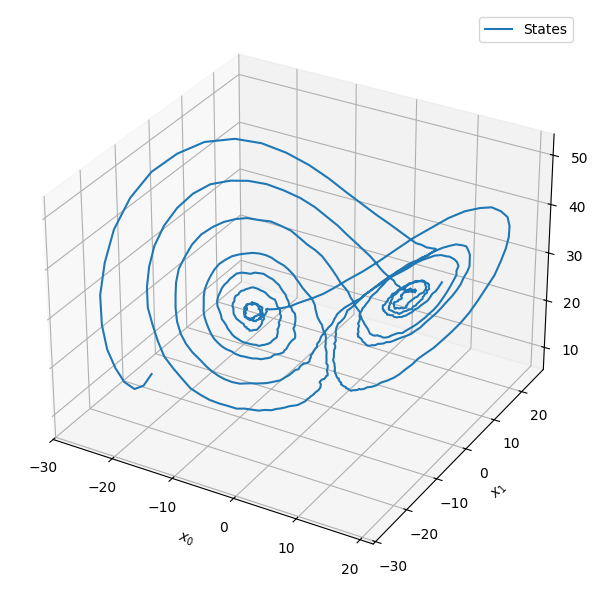

In [4]:
obs = synthetic_samples["observations"][0]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    synthetic_samples["states"][0][:, 0],
    synthetic_samples["states"][0][:, 1],
    synthetic_samples["states"][0][:, 2],
    label="States",
)

ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.set_zlabel("$x_2$")
ax.legend()
plt.tight_layout()
plt.show()


## Bayesian Inference via Simulation

In the discrete-time system, one option for Bayesian inference is to simply "unroll" the dynamical system into a normal probabilistic program. This internally does something like the following, but more efficiently using `jax.scan`:

```python
def simulated_program(...):
    # Probabilistic program before dsx.sample_ds
    # ...
    # dsx.sample_ds(...):
    
    T = len(obs_times)

    x_prev = numpyro.sample("x_0", initial_condition)
    y_0 = numpyro.sample("y_0", dynamics.observation_model(x=x_prev, t=obs_times[0]))

    for t_idx in range(T-1):
        t_now = obs_times[t_idx]
        t_next = obs_times[t_idx+1]

        x_t = numpyro.sample(f"x_{t_idx+1}", dynamics.state_evolution(x=x_prev, t=t_now, t_next=t_next))
        y_t = numpyro.sample(f"y_{t_idx+1}", dynamics.observation_model(x=x_t, t=t_next), obs=obs_values[t_idx+1])
```

This allows us to perform direct, joint inference over the states and parameters. This is unbiased and can work for small systems, though the dimensionality of the resulting Monte Carlo scales with $T$, and therefore becomes inefficient quickly. Let's see this in action for our current example; to make a `data_conditioned_model`, we will wrap in the simulator once again, just now including observations in our `Context`:

In [5]:
obs_values = synthetic_samples["observations"][0]
observations_trajectory = Trajectory(times=obs_times, values=obs_values)
context = Context(observations=observations_trajectory)

def data_conditioned_model():
    with DiscreteTimeSimulator():
        with Condition(context=context):
            return discrete_time_l63_model()
        

The resulting model is directly compatible with `numpyro` inference tools, which will perform joint (parameter, state) inference. For example, using NUTS:

In [6]:
from numpyro.infer import MCMC, NUTS
import jax.random as jr

mcmc_key = jr.PRNGKey(42)

nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(nuts_kernel, num_samples=100, num_warmup=100)
mcmc.run(mcmc_key)

posterior_samples = mcmc.get_samples()

/Users/danwaxman/Documents/dynestyx/dsx/dynamical_models.py:54: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(
sample: 100%|██████████| 200/200 [01:24<00:00,  2.37it/s, 1023 steps of size 1.11e-03. acc. prob=0.90]


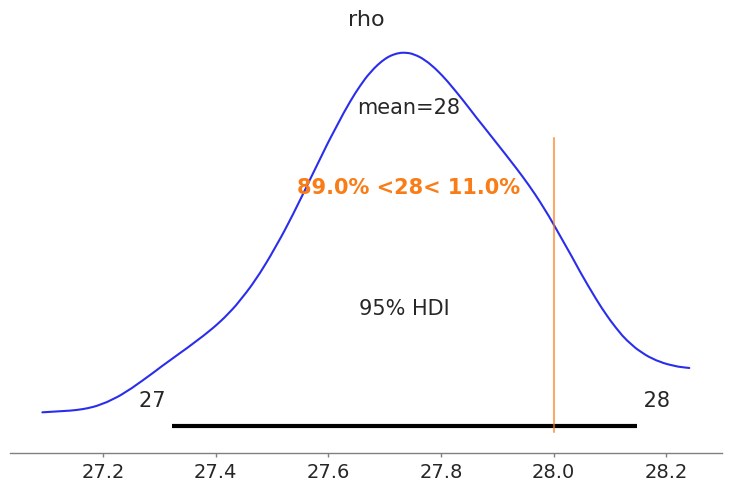

In [7]:
import arviz as az

az.style.use("arviz-white")

# For plotting reasons
parameter_posterior_samples = {"rho": posterior_samples["rho"]}

az.plot_posterior(parameter_posterior_samples, var_names=["rho"], hdi_prob=0.95, ref_val=28.0)

plt.show()


We also get *smoothing* estimates of the states. 

In [8]:
posterior_samples["states"].shape

(100, 999, 3)

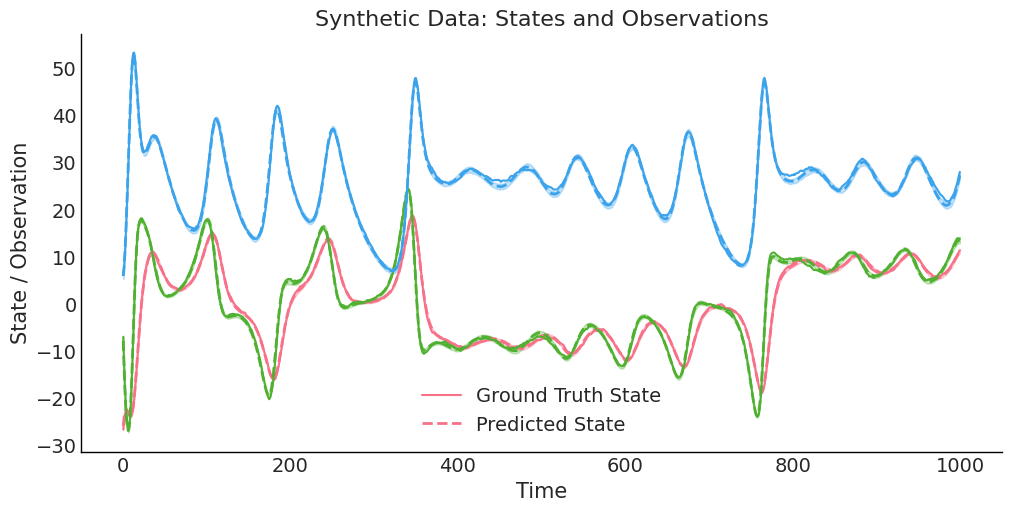

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

times = synthetic_samples["times"][0]
synthetic_states = synthetic_samples["states"][0]
states = posterior_samples["states"]

median = jnp.median(states, axis=0)  # (T, D)
p10 = jnp.percentile(states, 10, axis=0)  # (T, D)
p90 = jnp.percentile(states, 90, axis=0)  # (T, D)
colors = sns.color_palette("husl", 3)

for d in range(3):
    label = "Ground Truth State" if d == 0 else None
    plt.plot(times, synthetic_states[:, d], label=label, color=colors[d])
    plt.fill_between(times, p10[:, d], p90[:, d], alpha=0.3, color=colors[d])
    label = "Predicted State" if d == 0 else None
    plt.plot(times, median[:, d], label=label, lw=2, ls="--", color=colors[d])

plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("State / Observation")
sns.despine()
plt.legend()
plt.show()
